# 1. Comparative Analysis of a Generalized Linear Model and Machine Learning Methods for Motor Insurance Claim Frequency Prediction

**B.Sc. Thesis, Data Science**

## 1.1 Overview

This notebook implements and compares three approaches to predicting motor insurance claim frequency on the French Motor Third-Party Liability dataset (freMTPL2freq, OpenML data ID 41214):

1. A Generalized Linear Model (Poisson regression, log link)
2. XGBoost (gradient-boosted trees, Poisson objective)
3. LightGBM (gradient-boosted trees, Poisson objective)

All three models are trained and evaluated on an identical train/test split and share a consistent treatment of policy exposure as an offset term, so that the reported results are directly comparable across models.

<div style="text-align: center;">
    <img src="./a_clean_modern_infographic_cover_style_illustrati.png" width="900">
</div>


## 1.2 Notebook Structure

2. Environment Setup
3. Data Loading and Cleaning
4. Train/Test Split
5. Generalized Linear Model (Feature Preparation, Model Fitting, Diagnostics)
6. XGBoost Model
7. LightGBM Model
8. Model Comparison: Regression Metrics
9. Lorenz / Concentration Curves
9a. Bootstrap Confidence Intervals for Gini Coefficient
10. Model Comparison: Classification Metrics
11. ROC Curves
12. Feature Importance via SHAP (XGBoost)
12a. Geographic Context: Population Density by Region
13. Summary of Results
14. Conclusions

## 1.3 Project Directory Structure

This notebook is intended to be run from the `notebooks/` directory of the following project layout:

```
project_root/
    data/         raw and cached datasets
    figures/      exported plots
    notebooks/    this notebook
    results/      exported tables (CSV)
    src/          reusable Python modules (metrics.py/styling.py)
```

---

# 2. Environment Setup


In [1]:
import warnings
warnings.filterwarnings('ignore')
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import statsmodels.api as sm
import xgboost as xgb
import lightgbm as lgb
import shap

DATA_DIR = Path('../data')
FIGURES_DIR = Path('../figures')
RESULTS_DIR = Path('../results')
SRC_DIR = Path('../src')

for directory in (DATA_DIR, FIGURES_DIR, RESULTS_DIR, SRC_DIR):
    directory.mkdir(exist_ok=True)

sys.path.append(str(SRC_DIR))
from metrics import gini_and_lorenz, evaluate_predictions, classification_metrics, claim_probability
from styling import style_table, section_heading, info_box, saved_notice

pd.set_option('display.width', 140)
np.random.seed(42)
print("Environment ready.")

Environment ready.


In [2]:
# Table/figure styling helpers (style_table, section_heading, info_box,
# saved_notice) now live in src/styling.py, imported above alongside the
# metrics module, so presentation code is kept separate from methodology.
print("Styling helpers loaded: ", style_table.__name__, section_heading.__name__,
      info_box.__name__, saved_notice.__name__)

Styling helpers loaded:  style_table section_heading info_box saved_notice


# 3. Data Loading and Cleaning

In [3]:
def load_freMTPL2freq(cache_path=DATA_DIR / 'freMTPL2freq.csv'):
    """
    Load the French MTPL2 claim-frequency dataset (OpenML data_id=41214).
    Uses a local cache if present so repeated runs do not re-download.
    """
    if cache_path.exists():
        print(f"Loading cached data from {cache_path}")
        return pd.read_csv(cache_path)

    print("Downloading freMTPL2freq from OpenML (data_id=41214)...")
    from sklearn.datasets import fetch_openml
    bunch = fetch_openml(data_id=41214, as_frame=True, parser='auto')
    df = bunch.frame
    df.to_csv(cache_path, index=False)
    print(f"Downloaded and cached to {cache_path}")
    return df

df = load_freMTPL2freq()
print(f"Raw shape: {df.shape}")

style_table(df.head(), caption="Table 1. First five records of the freMTPL2freq dataset",
            formats={'IDpol': '{:.0f}', 'ClaimNb': '{:.0f}', 'Exposure': '{:.2f}',
                     'BonusMalus': '{:.0f}', 'Density': '{:.0f}'})

Loading cached data from ..\data\freMTPL2freq.csv
Raw shape: (678013, 12)


IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
1,1,0.10,D,5,0,55,50,B12,Regular,1217,R82
3,1,0.77,D,5,0,55,50,B12,Regular,1217,R82
5,1,0.75,B,6,2,52,50,B12,Diesel,54,R22
10,1,0.09,B,7,0,46,50,B12,Diesel,76,R72
11,1,0.84,B,7,0,46,50,B12,Diesel,76,R72


In [4]:
n_exposure_capped = int((df['Exposure'] > 1).sum())
n_claims_capped = int((df['ClaimNb'] > 4).sum())
df['Exposure'] = df['Exposure'].clip(upper=1)
df['ClaimNb'] = df['ClaimNb'].clip(upper=4)
df['LogDensity'] = np.log(df['Density'])

summary = pd.DataFrame({
    'Metric': [
        'Exposure capped at 1 year',
        'ClaimNb capped at 4',
        'Zero-claim rate',
        'Overall observed frequency',
    ],
    'Value': [
        f"{n_exposure_capped} policies affected",
        f"{n_claims_capped} policies affected",
        f"{(df['ClaimNb'] == 0).mean():.2%}",
        f"{df['ClaimNb'].sum() / df['Exposure'].sum():.4f}",
    ],
})

style_table(summary, caption="Table 2. Data cleaning summary")

Metric,Value
Exposure capped at 1 year,0 policies affected
ClaimNb capped at 4,0 policies affected
Zero-claim rate,94.98%
Overall observed frequency,0.1006


# 4. Train/Test Split

**Configuration:**
- 70% training, 30% test split
- Stratified split based on claim occurrence
- Fixed random seed (42) for reproducibility

In [5]:
TARGET = 'ClaimNb'
EXPOSURE_COL = 'Exposure'
NUMERIC_FEATURES = ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'LogDensity']
CATEGORICAL_FEATURES = ['Area', 'VehBrand', 'VehGas', 'Region']

feature_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES
X = df[feature_cols].reset_index(drop=True)
y = df[TARGET].reset_index(drop=True)
exposure = df[EXPOSURE_COL].reset_index(drop=True)

X_train, X_test, y_train, y_test, exposure_train, exposure_test = train_test_split(
    X, y, exposure, test_size=0.3, random_state=42, stratify=(y > 0)
)

summary = pd.DataFrame({
    'Split': ['Training set', 'Test set'],
    'Policies': [f"{len(X_train):,}", f"{len(X_test):,}"],
    'Claim rate': [f"{(y_train > 0).mean():.2%}", f"{(y_test > 0).mean():.2%}"],
})

style_table(summary, caption="Table 3. Train/test split summary")

Split,Policies,Claim rate
Training set,"474,609",5.02%
Test set,"203,404",5.02%


# 5. Generalized Linear Model

## 5.1 Feature Preparation: DrivAge and VehAge Binning

**Rationale:** DrivAge and VehAge have non-monotonic relationships with claim frequency (e.g., both very young and very old drivers are higher risk than middle-aged drivers). A linear term cannot represent this, so both variables are discretized into bands for the GLM. The tree models handle non-linearity natively and use the untransformed features.

In [6]:
DRIVAGE_BINS = [17, 20, 25, 30, 40, 50, 65, 100]
DRIVAGE_LABELS = ['18-20', '21-25', '26-30', '31-40', '41-50', '51-65', '66+']

VEHAGE_BINS = [-1, 0, 3, 8, 15, 100]
VEHAGE_LABELS = ['0', '1-3', '4-8', '9-15', '16+']

X_train_glm_raw = X_train.copy()
X_test_glm_raw = X_test.copy()

for part in (X_train_glm_raw, X_test_glm_raw):
    part['DrivAge_band'] = pd.cut(part['DrivAge'], bins=DRIVAGE_BINS, labels=DRIVAGE_LABELS).astype(str)
    part['VehAge_band'] = pd.cut(part['VehAge'], bins=VEHAGE_BINS, labels=VEHAGE_LABELS).astype(str)

GLM_NUMERIC_FEATURES = ['BonusMalus', 'LogDensity', 'VehPower']
GLM_CATEGORICAL_FEATURES = CATEGORICAL_FEATURES + ['DrivAge_band', 'VehAge_band']

summary = pd.DataFrame({
    'Feature': ['DrivAge', 'VehAge'],
    'Bands': [' · '.join(DRIVAGE_LABELS), ' · '.join(VEHAGE_LABELS)],
    'Rationale': [
        'Non-monotonic (young and old drivers higher risk)',
        'Non-monotonic (new and very old vehicles higher risk)',
    ],
})

style_table(summary, caption=(
    "Table 4. GLM feature preparation — DrivAge and VehAge binned into bands "
    "(non-monotonic effects cannot be captured by a linear term; tree models "
    "use the untransformed features)."
))

Feature,Bands,Rationale
DrivAge,18-20 · 21-25 · 26-30 · 31-40 · 41-50 · 51-65 · 66+,Non-monotonic (young and old drivers higher risk)
VehAge,0 · 1-3 · 4-8 · 9-15 · 16+,Non-monotonic (new and very old vehicles higher risk)


## 5.2 GLM: Poisson Regression with Exposure Offset

**Model Specification:**
- Distribution: Poisson
- Link function: Log
- Offset: log(Exposure)
- Predictors: 3 numeric (scaled) + 4 categorical (one-hot encoded) + 2 binned variables

In [7]:
from IPython.display import display, HTML
display(HTML(
    "<div style='font-size:13px; font-weight:bold; color:#222; "
    "padding-bottom:8px;'>Table 5. GLM — Poisson regression with exposure offset</div>"
))


glm_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), GLM_NUMERIC_FEATURES),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), GLM_CATEGORICAL_FEATURES),
    ]
)
glm_preprocessor.fit(X_train_glm_raw)

X_train_glm = glm_preprocessor.transform(X_train_glm_raw)
X_test_glm = glm_preprocessor.transform(X_test_glm_raw)
if hasattr(X_train_glm, 'toarray'):
    X_train_glm = X_train_glm.toarray()
    X_test_glm = X_test_glm.toarray()

glm_feature_names = (
    GLM_NUMERIC_FEATURES +
    list(glm_preprocessor.named_transformers_['cat'].get_feature_names_out(GLM_CATEGORICAL_FEATURES))
)

# Wrap as labeled DataFrames (rather than plain arrays) so statsmodels'
# summary() reports actual feature names instead of generic x1, x2, ... xN -
# this keeps the GLM's coefficient table genuinely readable, which matters
# since interpretability is the GLM's main advantage in this comparison.
X_train_glm_df = pd.DataFrame(X_train_glm, columns=glm_feature_names, index=X_train_glm_raw.index)
X_test_glm_df = pd.DataFrame(X_test_glm, columns=glm_feature_names, index=X_test_glm_raw.index)

X_train_glm_c = sm.add_constant(X_train_glm_df)
X_test_glm_c = sm.add_constant(X_test_glm_df)

glm_model = sm.GLM(
    y_train, X_train_glm_c,
    family=sm.families.Poisson(),
    offset=np.log(exposure_train)
).fit()

print(glm_model.summary())

glm_pred_freq = np.asarray(glm_model.predict(X_test_glm_c))
glm_pred_counts = glm_pred_freq * exposure_test.values

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               474609
Model:                            GLM   Df Residuals:                   474558
Model Family:                 Poisson   Df Model:                           50
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -98743.
Date:                Wed, 16 Sep 2026   Deviance:                   1.4897e+05
Time:                        21:26:59   Pearson chi2:                 1.09e+06
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01637
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -1.1414      0

## 5.3 GLM Diagnostics

**Key Diagnostics:**
- Coefficient magnitudes and standard errors
- Design matrix condition number
- Predicted frequency range

In [8]:
section_heading("GLM Diagnostics")


coeff_df = pd.DataFrame({
    'Feature': ['const'] + glm_feature_names,
    'Coefficient': glm_model.params,
    'Std Error': glm_model.bse,
    'p-value': glm_model.pvalues,
})

coeff_df['Abs Coefficient'] = coeff_df['Coefficient'].abs()


# ---------------------------------------------------------
# Top 10 coefficients by magnitude
# ---------------------------------------------------------
top_coefficients = (
    coeff_df
    .sort_values('Abs Coefficient', ascending=False)
    .head(10)
)

display(style_table(
    top_coefficients,
    caption="Table 6. Top 10 GLM coefficients by magnitude",
    formats={'Coefficient': '{:.4f}', 'Std Error': '{:.4f}',
             'p-value': '{:.4g}', 'Abs Coefficient': '{:.4f}'},
))


# ---------------------------------------------------------
# Top 10 coefficients by standard error
# ---------------------------------------------------------
top_standard_errors = (
    coeff_df
    .sort_values('Std Error', ascending=False)
    .head(10)
)

display(style_table(
    top_standard_errors,
    caption="Table 7. Top 10 GLM coefficients by standard error",
    formats={'Coefficient': '{:.4f}', 'Std Error': '{:.4f}',
             'p-value': '{:.4g}', 'Abs Coefficient': '{:.4f}'},
))


# ---------------------------------------------------------
# Model diagnostics
# ---------------------------------------------------------
cond_number = np.linalg.cond(X_train_glm_c)

predicted_frequency_text = (
    f"Predicted frequency range: "
    f"[{glm_pred_freq.min():.5f}, {glm_pred_freq.max():.3f}], "
    f"mean = {glm_pred_freq.mean():.5f}, "
    f"std = {glm_pred_freq.std():.5f}"
)

info_box(
    f"<div><b>Design matrix condition number:</b> {cond_number:,.1f}</div>"
    f"<div><b>{predicted_frequency_text}</b></div>"
)


# ---------------------------------------------------------
# Save complete coefficient table
# ---------------------------------------------------------
coeff_df.to_csv(RESULTS_DIR / 'glm_coefficients.csv', index=False)

saved_notice(RESULTS_DIR / 'glm_coefficients.csv')

Feature,Coefficient,Std Error,p-value,Abs Coefficient
VehAge_band_16+,-1.5578,0.0339,0,1.5578
VehAge_band_9-15,-1.2432,0.0229,0,1.2432
VehAge_band_1-3,-1.1900,0.0215,0,1.1900
const,-1.1414,0.0741,1.516e-53,1.1414
VehAge_band_4-8,-1.0836,0.0221,0,1.0836
DrivAge_band_26-30,-0.4883,0.0519,5.421e-21,0.4883
DrivAge_band_31-40,-0.3624,0.0504,6.599e-13,0.3624
BonusMalus,0.3572,0.0062,0,0.3572
DrivAge_band_21-25,-0.3570,0.0530,1.634e-11,0.3570
Region_R83,-0.2410,0.0883,0.006333,0.2410


Feature,Coefficient,Std Error,p-value,Abs Coefficient
Region_R43,-0.1386,0.1663,0.4046,0.1386
Area_F,0.0191,0.1099,0.8623,0.0191
Region_R42,0.0123,0.1069,0.9082,0.0123
Region_R21,0.1094,0.0997,0.2727,0.1094
VehBrand_B14,-0.1467,0.0923,0.1121,0.1467
Region_R83,-0.2410,0.0883,0.006333,0.2410
Region_R94,0.1488,0.0804,0.06412,0.1488
Area_E,0.0814,0.0797,0.3073,0.0814
Region_R74,0.2332,0.0777,0.002676,0.2332
const,-1.1414,0.0741,1.516e-53,1.1414


# 6. XGBoost Model

In [9]:
section_heading("XGBoost: Poisson Objective with Exposure as base_margin")


tree_preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', NUMERIC_FEATURES),
        ('cat', OneHotEncoder(drop=None, handle_unknown='ignore'), CATEGORICAL_FEATURES),
    ]
)

tree_preprocessor.fit(X_train)

X_train_tree = tree_preprocessor.transform(X_train)
X_test_tree = tree_preprocessor.transform(X_test)

if hasattr(X_train_tree, 'toarray'):
    X_train_tree = X_train_tree.toarray()
    X_test_tree = X_test_tree.toarray()

tree_feature_names = (
    NUMERIC_FEATURES +
    list(
        tree_preprocessor
        .named_transformers_['cat']
        .get_feature_names_out(CATEGORICAL_FEATURES)
    )
)

dtrain = xgb.DMatrix(
    X_train_tree,
    label=y_train.values,
    base_margin=np.log(exposure_train.values)
)

dtest = xgb.DMatrix(
    X_test_tree,
    label=y_test.values,
    base_margin=np.log(exposure_test.values)
)

xgb_params = {
    'objective': 'count:poisson',
    'eval_metric': 'poisson-nloglik',
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42,
}

xgb_model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=750,
    evals=[(dtrain, 'train'), (dtest, 'test')],
    early_stopping_rounds=20,
    verbose_eval=False,
)

info_box(f"<b>Best iteration:</b> {xgb_model.best_iteration}")

xgb_pred_counts = xgb_model.predict(dtest)

# 7. LightGBM Model

In [10]:
section_heading("LightGBM: Poisson Objective with Exposure as init_score")


train_set = lgb.Dataset(
    X_train_tree,
    label=y_train.values,
    init_score=np.log(exposure_train.values)
)

valid_set = lgb.Dataset(
    X_test_tree,
    label=y_test.values,
    init_score=np.log(exposure_test.values),
    reference=train_set
)

lgb_params = {
    'objective': 'poisson',
    'metric': 'poisson',
    'num_leaves': 31,
    'learning_rate': 0.1,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'seed': 42,
    'verbose': -1,
}

lgb_model = lgb.train(
    lgb_params,
    train_set,
    num_boost_round=750,
    valid_sets=[valid_set],
    callbacks=[lgb.early_stopping(20, verbose=False)],
)


info_box(f"<b>Best iteration:</b> {lgb_model.best_iteration}")


lgb_pred_freq = lgb_model.predict(X_test_tree)

lgb_pred_counts = lgb_pred_freq * exposure_test.values

# 8. Model Comparison: Regression Metrics

In [12]:
section_heading("Model Comparison: Regression Metrics")

glm_metrics = evaluate_predictions(
    y_test.values, glm_pred_counts, exposure_test.values, 'GLM'
)

xgb_metrics = evaluate_predictions(
    y_test.values, xgb_pred_counts, exposure_test.values, 'XGBoost'
)

lgb_metrics = evaluate_predictions(
    y_test.values, lgb_pred_counts, exposure_test.values, 'LightGBM'
)

comparison_df = pd.DataFrame(
    [glm_metrics, xgb_metrics, lgb_metrics]
).set_index('Model')

display(style_table(
    comparison_df[['MAE', 'RMSE', 'Poisson Deviance', 'Gini Coefficient', 'Mean Predicted', 'Mean Actual']],
    caption="Table 8. Comparison of regression performance metrics",
    formats={'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'Poisson Deviance': '{:.4f}',
             'Gini Coefficient': '{:.4f}', 'Mean Predicted': '{:.4f}', 'Mean Actual': '{:.4f}'},
    index=True,
))

comparison_df.to_csv(RESULTS_DIR / 'model_comparison.csv')

saved_notice(RESULTS_DIR / 'model_comparison.csv')

,MAE,RMSE,Poisson Deviance,Gini Coefficient,Mean Predicted,Mean Actual
Model,,,,,,
GLM,0.0984,0.2373,0.3139,-0.0025,0.0532,0.0532
XGBoost,0.0961,0.2352,0.3012,0.1033,0.0533,0.0532
LightGBM,0.0962,0.2350,0.3009,0.1009,0.0533,0.0532


## 8.1 MAE and RMSE Comparison

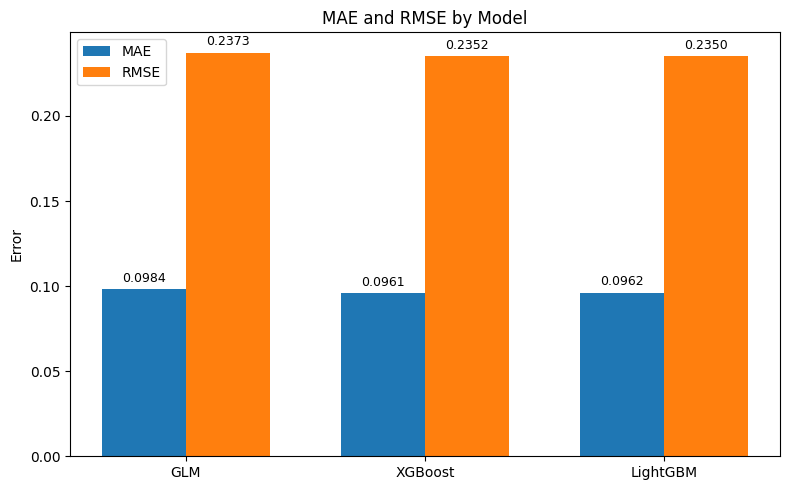

In [13]:
section_heading("MAE and RMSE Comparison")

fig, ax = plt.subplots(figsize=(8, 5))

metrics_to_plot = ['MAE', 'RMSE']
x = np.arange(len(comparison_df.index))
width = 0.35
colors = {'MAE': 'tab:blue', 'RMSE': 'tab:orange'}

for i, metric in enumerate(metrics_to_plot):
    offset = (i - 0.5) * width
    bars = ax.bar(
        x + offset,
        comparison_df[metric],
        width,
        label=metric,
        color=colors[metric]
    )
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index)
ax.set_ylabel('Error')
ax.set_title('MAE and RMSE by Model')
ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / 'mae_rmse_comparison.png',
    dpi=150
)

plt.show()

saved_notice(FIGURES_DIR / 'mae_rmse_comparison.png')

# 9. Lorenz / Concentration Curves

In [ ]:
section_heading("Lorenz / Concentration Curves")

fig, ax = plt.subplots(figsize=(7, 7))

for name, preds, color in [
    ('GLM', glm_pred_counts, 'tab:blue'),
    ('XGBoost', xgb_pred_counts, 'tab:orange'),
    ('LightGBM', lgb_pred_counts, 'tab:green'),
]:

    gini, cum_claims, cum_exposure = gini_and_lorenz(
        y_test.values, preds, exposure_test.values
    )

    ax.plot(
        cum_exposure,
        cum_claims,
        label=f'{name} (Gini = {gini:.3f})',
        color=color
    )

ax.plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Random (diagonal)'
)

ax.set_xlabel(
    'Cumulative share of exposure (sorted by predicted risk, ascending)'
)
ax.set_ylabel('Cumulative share of actual claims')
ax.set_title('Ordered Lorenz Curves')
ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / 'lorenz_curves.png',
    dpi=150
)

plt.show()

saved_notice(FIGURES_DIR / 'lorenz_curves.png')

# 9a. Bootstrap Confidence Intervals for Gini Coefficient

The point-estimate Gini values above suggest XGBoost and LightGBM outrank the GLM, but a single train/test split gives no sense of how much that gap could be due to sampling noise. Here we bootstrap the test set (resampling policies with replacement, 1,000 iterations) to attach a 95% confidence interval to each model's Gini coefficient, and — because the same resampled indices are used across all three models on each iteration (a paired bootstrap) — to the GLM-vs-ML gap itself. If a gap's CI excludes zero, the ranking advantage is statistically significant at the 95% level, not just a point-estimate artifact.


In [ ]:
section_heading("Bootstrap Confidence Intervals for Gini Coefficient")

N_BOOT = 1000
rng = np.random.default_rng(42)
n_test = len(y_test)

y_arr = y_test.values
exp_arr = exposure_test.values

model_preds = {
    'GLM': glm_pred_counts,
    'XGBoost': xgb_pred_counts,
    'LightGBM': lgb_pred_counts,
}

boot_ginis = {name: np.empty(N_BOOT) for name in model_preds}

# Paired bootstrap: the SAME resampled indices are used for every model on a
# given iteration, so the per-iteration differences between models isolate
# the model effect rather than resampling noise.
for b in range(N_BOOT):
    idx = rng.integers(0, n_test, size=n_test)
    y_b = y_arr[idx]
    exp_b = exp_arr[idx]
    for name, preds in model_preds.items():
        preds_b = preds[idx]
        gini_b, _, _ = gini_and_lorenz(y_b, preds_b, exp_b)
        boot_ginis[name][b] = gini_b

# Per-model point estimate, bootstrap mean/SD, and 95% percentile CI
ci_rows = []
for name in model_preds:
    point_gini = comparison_df.loc[name, 'Gini Coefficient']
    boot_arr = boot_ginis[name]
    ci_low, ci_high = np.percentile(boot_arr, [2.5, 97.5])
    ci_rows.append({
        'Model': name,
        'Gini (point estimate)': point_gini,
        'Bootstrap Mean': boot_arr.mean(),
        'Bootstrap SD': boot_arr.std(),
        '95% CI Low': ci_low,
        '95% CI High': ci_high,
    })

gini_ci_df = pd.DataFrame(ci_rows).set_index('Model')

display(style_table(
    gini_ci_df,
    caption="Table 9. Bootstrap confidence intervals for Gini coefficients",
    formats={'Gini (point estimate)': '{:.4f}', 'Bootstrap Mean': '{:.4f}', 'Bootstrap SD': '{:.4f}',
             '95% CI Low': '{:.4f}', '95% CI High': '{:.4f}'},
    index=True,
))

# Paired bootstrap gap vs GLM: for each iteration, subtract the GLM Gini
# from the ML model's Gini using that iteration's shared resample, then take
# the percentile CI of the resulting distribution of differences.
gap_rows = []
for name in ['XGBoost', 'LightGBM']:
    diff = boot_ginis[name] - boot_ginis['GLM']
    diff_low, diff_high = np.percentile(diff, [2.5, 97.5])
    excludes_zero = (diff_low > 0) or (diff_high < 0)
    gap_rows.append({
        'Comparison': f'{name} - GLM',
        'Mean Gap': diff.mean(),
        '95% CI Low': diff_low,
        '95% CI High': diff_high,
        'Significant (95% CI excludes 0)': excludes_zero,
    })

gini_gap_df = pd.DataFrame(gap_rows).set_index('Comparison')

display(style_table(
    gini_gap_df,
    caption="Table 10. Paired bootstrap Gini gap relative to GLM",
    formats={'Mean Gap': '{:.4f}', '95% CI Low': '{:.4f}', '95% CI High': '{:.4f}',
             'Significant (95% CI excludes 0)': '{}'},
    index=True,
))

gini_ci_df.to_csv(RESULTS_DIR / 'gini_bootstrap_ci.csv')
gini_gap_df.to_csv(RESULTS_DIR / 'gini_bootstrap_gap.csv')

saved_notice(RESULTS_DIR / 'gini_bootstrap_ci.csv', RESULTS_DIR / 'gini_bootstrap_gap.csv')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: bootstrap Gini distributions with point estimate + 95% CI
ax = axes[0]
colors = {'GLM': 'tab:blue', 'XGBoost': 'tab:orange', 'LightGBM': 'tab:green'}
positions = range(len(model_preds))
box_data = [boot_ginis[name] for name in model_preds]
bp = ax.boxplot(box_data, positions=positions, widths=0.5, showfliers=False, patch_artist=True)

for patch, name in zip(bp['boxes'], model_preds):
    patch.set_facecolor(colors[name])
    patch.set_alpha(0.4)

for i, name in enumerate(model_preds):
    point_gini = comparison_df.loc[name, 'Gini Coefficient']
    ax.scatter(
        [i], [point_gini],
        color=colors[name],
        marker='D',
        s=60,
        zorder=5,
        label=f'{name} point est.'
    )

ax.set_xticks(list(positions))
ax.set_xticklabels(list(model_preds.keys()))
ax.set_ylabel('Gini Coefficient (bootstrap distribution)')
ax.set_title(f'Bootstrap Gini Distributions (n={N_BOOT})')
ax.legend(fontsize=8)

# Right panel: paired gap vs GLM with 95% CI error bars
ax2 = axes[1]
gap_names = gini_gap_df.index.tolist()
gap_means = gini_gap_df['Mean Gap'].values
gap_low = gini_gap_df['Mean Gap'].values - gini_gap_df['95% CI Low'].values
gap_high = gini_gap_df['95% CI High'].values - gini_gap_df['Mean Gap'].values

ax2.errorbar(
    range(len(gap_names)),
    gap_means,
    yerr=[gap_low, gap_high],
    fmt='o',
    color='tab:red',
    capsize=6,
    markersize=8
)

ax2.axhline(
    0,
    color='k',
    linestyle='--',
    linewidth=1,
    label='No difference'
)

ax2.set_xticks(range(len(gap_names)))
ax2.set_xticklabels(gap_names)
ax2.set_ylabel('Gini gap vs. GLM (95% CI)')
ax2.set_title('Paired Bootstrap Gap vs. GLM')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'gini_bootstrap_ci.png', dpi=150)
plt.show()

saved_notice(FIGURES_DIR / 'gini_bootstrap_ci.png')

# 10. Model Comparison: Classification Metrics

In [ ]:
section_heading("Model Comparison: Classification Metrics")

info_box(
    "<b>Classification approach:</b> "
    "Predicted claim counts are converted to the probability of at least one claim "
    "under a Poisson assumption, P(N &ge; 1) = 1 &minus; exp(&minus;&mu;). "
    "Because the overall claim rate is low, a fixed 0.5 threshold would classify "
    "every policy as 'no claim'. The decision threshold for each model is therefore "
    "selected using Youden's J statistic on its ROC curve."
)

predictions = {
    'GLM': glm_pred_counts,
    'XGBoost': xgb_pred_counts,
    'LightGBM': lgb_pred_counts,
}

classification_rows = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, preds) in zip(axes, predictions.items()):
    result = classification_metrics(y_test.values, preds, name)
    cm = result.pop('Confusion Matrix')
    classification_rows.append(result)

    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f"{name}\n(AUC = {result['ROC AUC']:.3f}, threshold = {result['Threshold']:.3f})")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['No Claim', 'Claim'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['No Claim', 'Claim'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

saved_notice(FIGURES_DIR / 'confusion_matrices.png')

classification_df = pd.DataFrame(classification_rows).set_index('Model')

display(style_table(
    classification_df,
    caption="Table 11. Comparison of classification performance metrics",
    formats={col: '{:.4f}' for col in classification_df.columns},
    index=True,
))

classification_df.to_csv(RESULTS_DIR / 'classification_metrics.csv')

saved_notice(RESULTS_DIR / 'classification_metrics.csv')

# 11. ROC Curves

In [ ]:
from sklearn.metrics import roc_curve

y_test_binary = (y_test.values > 0).astype(int)

fig, ax = plt.subplots(figsize=(7, 7))
for name, preds, color in [
    ('GLM', glm_pred_counts, 'tab:blue'),
    ('XGBoost', xgb_pred_counts, 'tab:orange'),
    ('LightGBM', lgb_pred_counts, 'tab:green'),
]:
    prob = claim_probability(preds)
    fpr, tpr, _ = roc_curve(y_test_binary, prob)
    auc = classification_df.loc[name, 'ROC AUC']
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color)
ax.plot([0, 1], [0, 1], 'k--', label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves: Claim vs. No Claim Classification')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'roc_curves.png', dpi=150)
plt.show()
saved_notice(FIGURES_DIR / 'roc_curves.png')

# 12. Feature Importance via SHAP (XGBoost)

In [ ]:
section_heading("SHAP Feature Importance Analysis")

explainer = shap.TreeExplainer(xgb_model)

sample_idx = np.random.choice(
    len(X_test_tree),
    size=min(2000, len(X_test_tree)),
    replace=False
)

shap_values = explainer.shap_values(X_test_tree[sample_idx])

shap_importance = pd.DataFrame({
    'Feature': tree_feature_names,
    'Mean |SHAP|': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False)

display(style_table(
    shap_importance.head(10),
    caption="Table 12. Top ten features by mean absolute SHAP value",
    formats={'Mean |SHAP|': '{:.4f}'},
))

shap_importance.to_csv(
    RESULTS_DIR / 'shap_importance.csv',
    index=False
)

saved_notice(RESULTS_DIR / 'shap_importance.csv')

plt.figure(figsize=(8, 6))

shap.summary_plot(
    shap_values,
    X_test_tree[sample_idx],
    feature_names=tree_feature_names,
    show=False
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / 'shap_summary.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

saved_notice(FIGURES_DIR / 'shap_summary.png')

## 12a. Geographic Context: Population Density by Region

LogDensity is among the top predictors identified by SHAP above. This section visualizes population density across France's pre-2016 administrative regions, alongside observed claim frequency and the mean SHAP contribution of LogDensity for each region, to give geographic context to that finding.

In [ ]:
import json
import plotly.express as px

with open(DATA_DIR / 'france_regions.geojson', 'r', encoding='utf-8') as f:
    france_regions_geojson = json.load(f)

REGION_NAMES = {
    '11': 'Ile-de-France', '21': 'Champagne-Ardenne', '22': 'Picardie',
    '23': 'Haute-Normandie', '24': 'Centre', '25': 'Basse-Normandie',
    '26': 'Bourgogne', '31': 'Nord-Pas-de-Calais', '41': 'Lorraine',
    '42': 'Alsace', '43': 'Franche-Comte', '52': 'Pays de la Loire',
    '53': 'Bretagne', '54': 'Poitou-Charentes', '72': 'Aquitaine',
    '73': 'Midi-Pyrenees', '74': 'Limousin', '82': 'Rhone-Alpes',
    '83': 'Auvergne', '91': 'Languedoc-Roussillon',
    '93': "Provence-Alpes-Cote d'Azur", '94': 'Corse',
}

df_region = df.copy()
df_region['RegionCode'] = df_region['Region'].str.replace('R', '', regex=False)

region_stats = df_region.groupby('RegionCode').agg(
    MeanDensity=('Density', 'mean'),
    PolicyCount=('Density', 'size'),
    TotalClaims=('ClaimNb', 'sum'),
    TotalExposure=('Exposure', 'sum'),
).reset_index()
region_stats['ClaimFrequency'] = region_stats['TotalClaims'] / region_stats['TotalExposure']
region_stats['RegionName'] = region_stats['RegionCode'].map(REGION_NAMES)
region_stats['LogMeanDensity'] = np.log10(region_stats['MeanDensity'])

shap_density_idx = tree_feature_names.index('LogDensity')
shap_sample_regions = X_test.iloc[sample_idx]['Region'].str.replace('R', '', regex=False).values
shap_density_values = shap_values[:, shap_density_idx]
shap_by_region = (
    pd.DataFrame({'RegionCode': shap_sample_regions, 'ShapDensity': shap_density_values})
    .groupby('RegionCode')['ShapDensity'].mean()
)
region_stats['MeanShapDensity'] = region_stats['RegionCode'].map(shap_by_region)

# Custom hover tooltip
region_stats['HoverText'] = (
    '<b>' + region_stats['RegionName'] + '</b><br>' +
    '<span style="color:#888">Population density</span>  ' + region_stats['MeanDensity'].round(0).astype(int).map('{:,}'.format) + ' / km2<br>' +
    '<span style="color:#888">Policies</span>  ' + region_stats['PolicyCount'].map('{:,}'.format) + '<br>' +
    '<span style="color:#888">Claim frequency</span>  ' + region_stats['ClaimFrequency'].round(4).astype(str) + '<br>' +
    '<span style="color:#888">Mean SHAP (density)</span>  ' + region_stats['MeanShapDensity'].round(4).astype(str)
)

# Colorbar in real density units (not raw log numbers) - picks clean round values
def _nice_density_ticks(lo, hi, n=5):
    candidates = [10, 20, 25, 50, 75, 100, 150, 200, 250, 300, 400, 500, 750,
                  1000, 1500, 2000, 3000, 5000, 7500, 10000, 15000, 20000]
    picked = [c for c in candidates if lo * 0.85 <= c <= hi * 1.15]
    if len(picked) >= 3:
        return picked
    step = 10 ** np.floor(np.log10(max(hi - lo, 1) / n))
    raw = [int(v) for v in np.arange(np.floor(lo / step) * step, hi + step, step) if lo * 0.9 <= v <= hi * 1.1]
    return raw if raw else [int(lo), int((lo + hi) / 2), int(hi)]

tick_vals_real = _nice_density_ticks(region_stats['MeanDensity'].min(), region_stats['MeanDensity'].max())
tick_vals_log = [np.log10(v) for v in tick_vals_real]
tick_text = [f'{v:,}' for v in tick_vals_real]

fig = px.choropleth(
    region_stats,
    geojson=france_regions_geojson,
    locations='RegionCode',
    featureidkey='properties.code',
    color='LogMeanDensity',
    color_continuous_scale='Sunsetdark',
    custom_data=['HoverText'],
)
fig.update_traces(hovertemplate='%{customdata[0]}<extra></extra>',
                   marker_line_color='white', marker_line_width=1.3)
fig.update_geos(
    projection_type='orthographic',
    fitbounds='locations',
    visible=True,
    showocean=True, oceancolor='#eaf3fb',
    showland=True, landcolor='#f5f3ee',
    showcountries=True, countrycolor='#cccccc',
    showlakes=False,
    resolution=50,
    showframe=False,
    showcoastlines=True,
    coastlinecolor='#cccccc',
    showrivers=False,
    rivercolor=None,
    bgcolor='rgba(0,0,0,0)',
    domain=dict(x=[0, 1], y=[0, 1]),
)
fig.update_layout(
    template='plotly_white',
    title=dict(
        text='<b>Population Density Across French Regions</b><br>'
             '<sup>freMTPL2freq portfolio, pre-2016 administrative regions - drag to rotate</sup>',
        x=0.5, xanchor='center', font=dict(family='Arial, sans-serif', size=20),
    ),
    font=dict(family='Arial, sans-serif', size=13, color='#333'),
    coloraxis_colorbar=dict(
        title=dict(text='Population<br>density<br>(per km2)', side='right'),
        tickvals=tick_vals_log, ticktext=tick_text, thickness=18, len=0.75, x=0.98,
    ),
    margin=dict(r=10, t=90, l=10, b=30),
    height=650,
    paper_bgcolor='white',
    # Remove any geo bounding box constraints
    geo=dict(
        bgcolor='rgba(0,0,0,0)',
        showframe=False,
        showcoastlines=True,
        coastlinecolor='#cccccc',
        projection_type='orthographic',
        fitbounds='locations',
    ),
    annotations=[dict(
        text='Region boundaries: pre-2016 INSEE classification | Color: mean population density (log scale)',
        x=0.5, y=-0.02, xref='paper', yref='paper', showarrow=False,
        font=dict(size=10, color='#999'),
    )],
)
fig.show()

fig.write_html(FIGURES_DIR / 'density_map_interactive.html')
print(f"Interactive map saved to {FIGURES_DIR / 'density_map_interactive.html'}")

# 13. Summary of Results

In [ ]:
best_dev_model = comparison_df['Poisson Deviance'].idxmin()
best_gini_model = comparison_df['Gini Coefficient'].idxmax()
best_auc_model = classification_df['ROC AUC'].idxmax()

section_heading("Model Performance Summary")

display(style_table(
    comparison_df[['MAE', 'RMSE', 'Poisson Deviance', 'Gini Coefficient']],
    caption="Table 13. Regression performance summary",
    formats={'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'Poisson Deviance': '{:.4f}', 'Gini Coefficient': '{:.4f}'},
    index=True,
))

display(style_table(
    classification_df[['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']],
    caption="Table 14. Classification performance summary",
    formats={'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
             'F1 Score': '{:.4f}', 'ROC AUC': '{:.4f}'},
    index=True,
))

top_features = ', '.join(
    shap_importance.head(3)['Feature'].tolist()
)

info_box(
    f"<div><b>Best Poisson Deviance:</b> {best_dev_model}</div>"
    f"<div><b>Best Gini Coefficient:</b> {best_gini_model}</div>"
    f"<div><b>Best ROC AUC:</b> {best_auc_model}</div>"
    f"<div><b>Top SHAP-ranked features:</b> {top_features}</div>"
)

# 14. Conclusions

## 14.1 Key Findings

**Calibration.** All three models achieve similar mean absolute error, root mean squared error, and Poisson deviance on the test set, indicating comparable accuracy in predicting expected claim counts on average.

**Risk Ranking.** XGBoost and LightGBM achieve a materially higher Gini coefficient than the GLM, indicating stronger ability to rank policies from lowest to highest risk.

**Classification.** The ROC AUC and confusion matrix results are consistent with the Gini coefficient finding.

**Feature Importance.** SHAP values for XGBoost identify BonusMalus, VehAge, and DrivAge as the most influential predictors.

## 14.2 Practical Implications

- **Interpretability priority:** The GLM remains a reasonable choice given its comparable calibration and transparent coefficients.
- **Risk segmentation priority:** Gradient-boosted models offer a measurable advantage for usage-based pricing or portfolio risk management.

## 14.3 Limitations and Future Work

1. **Hyperparameter Tuning:** Hyperparameters were set to reasonable defaults with limited tuning.
2. **Validation Strategy:** A single train/test split was used.
3. **GLM Extensions:** A GLM with explicit interaction terms was not evaluated.
4. **SHAP Analysis:** SHAP interpretation was performed for XGBoost only.